In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Load processed data
df = pd.read_parquet('data/processed/t100_cleaned.parquet')
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nDate range: {df['DATE'].min()} to {df['DATE'].max()}")
print(f"\nRoutes: {df['ROUTE'].unique()}")

Shape: (360, 10)

Columns: ['YEAR', 'MONTH', 'ROUTE', 'ORIGIN', 'DEST', 'total_passengers', 'total_seats', 'num_carriers', 'avg_load_factor', 'DATE']

Date range: 2019-01-01 00:00:00 to 2023-12-01 00:00:00

Routes: ['JFK-LAX' 'LAX-JFK' 'LAX-SEA' 'MIA-ORD' 'ORD-MIA' 'SEA-LAX']


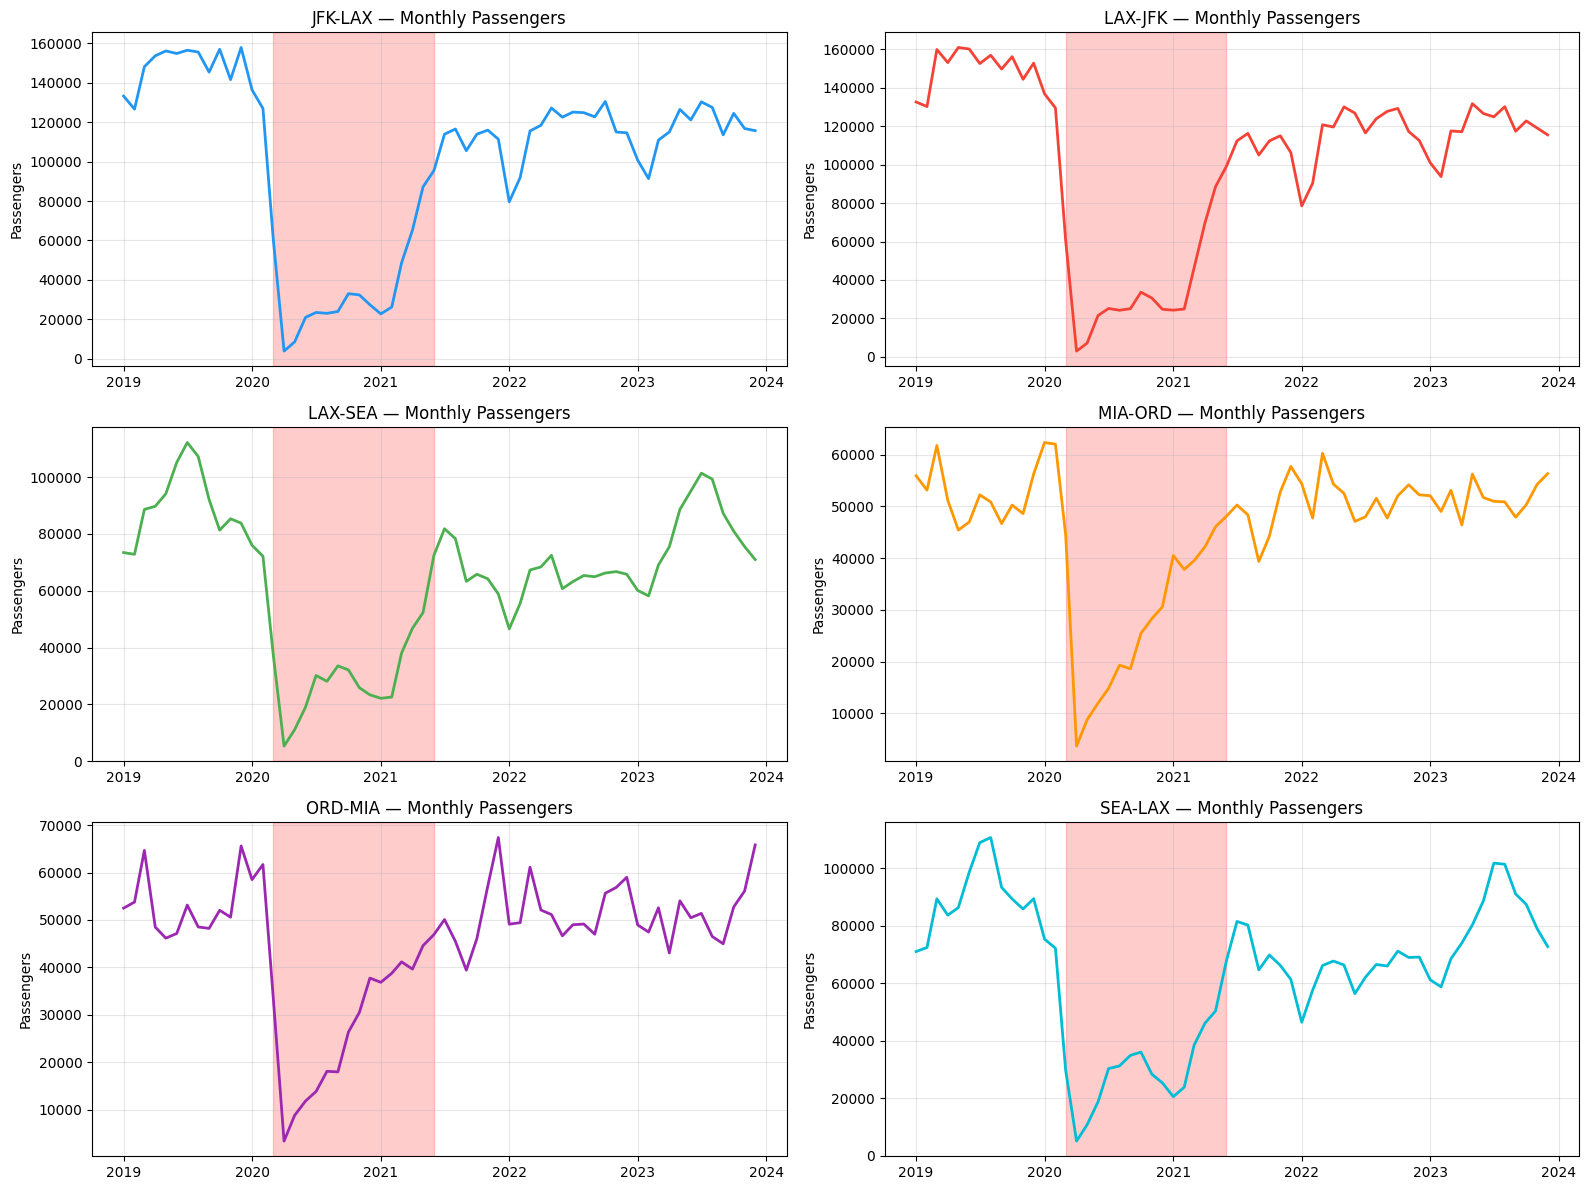

Saved to notebooks/demand_over_time.png


In [2]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

routes = df['ROUTE'].unique()
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

for i, route in enumerate(routes):
    route_df = df[df['ROUTE'] == route].sort_values('DATE')
    axes[i].plot(route_df['DATE'], route_df['total_passengers'], 
                 color=colors[i], linewidth=2)
    axes[i].set_title(f'{route} — Monthly Passengers', fontsize=12)
    axes[i].set_ylabel('Passengers')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].grid(True, alpha=0.3)
    
    # Mark COVID period
    axes[i].axvspan(pd.Timestamp('2020-03-01'), 
                    pd.Timestamp('2021-06-01'), 
                    alpha=0.2, color='red', label='COVID period')

plt.tight_layout()
plt.savefig('notebooks/demand_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to notebooks/demand_over_time.png")

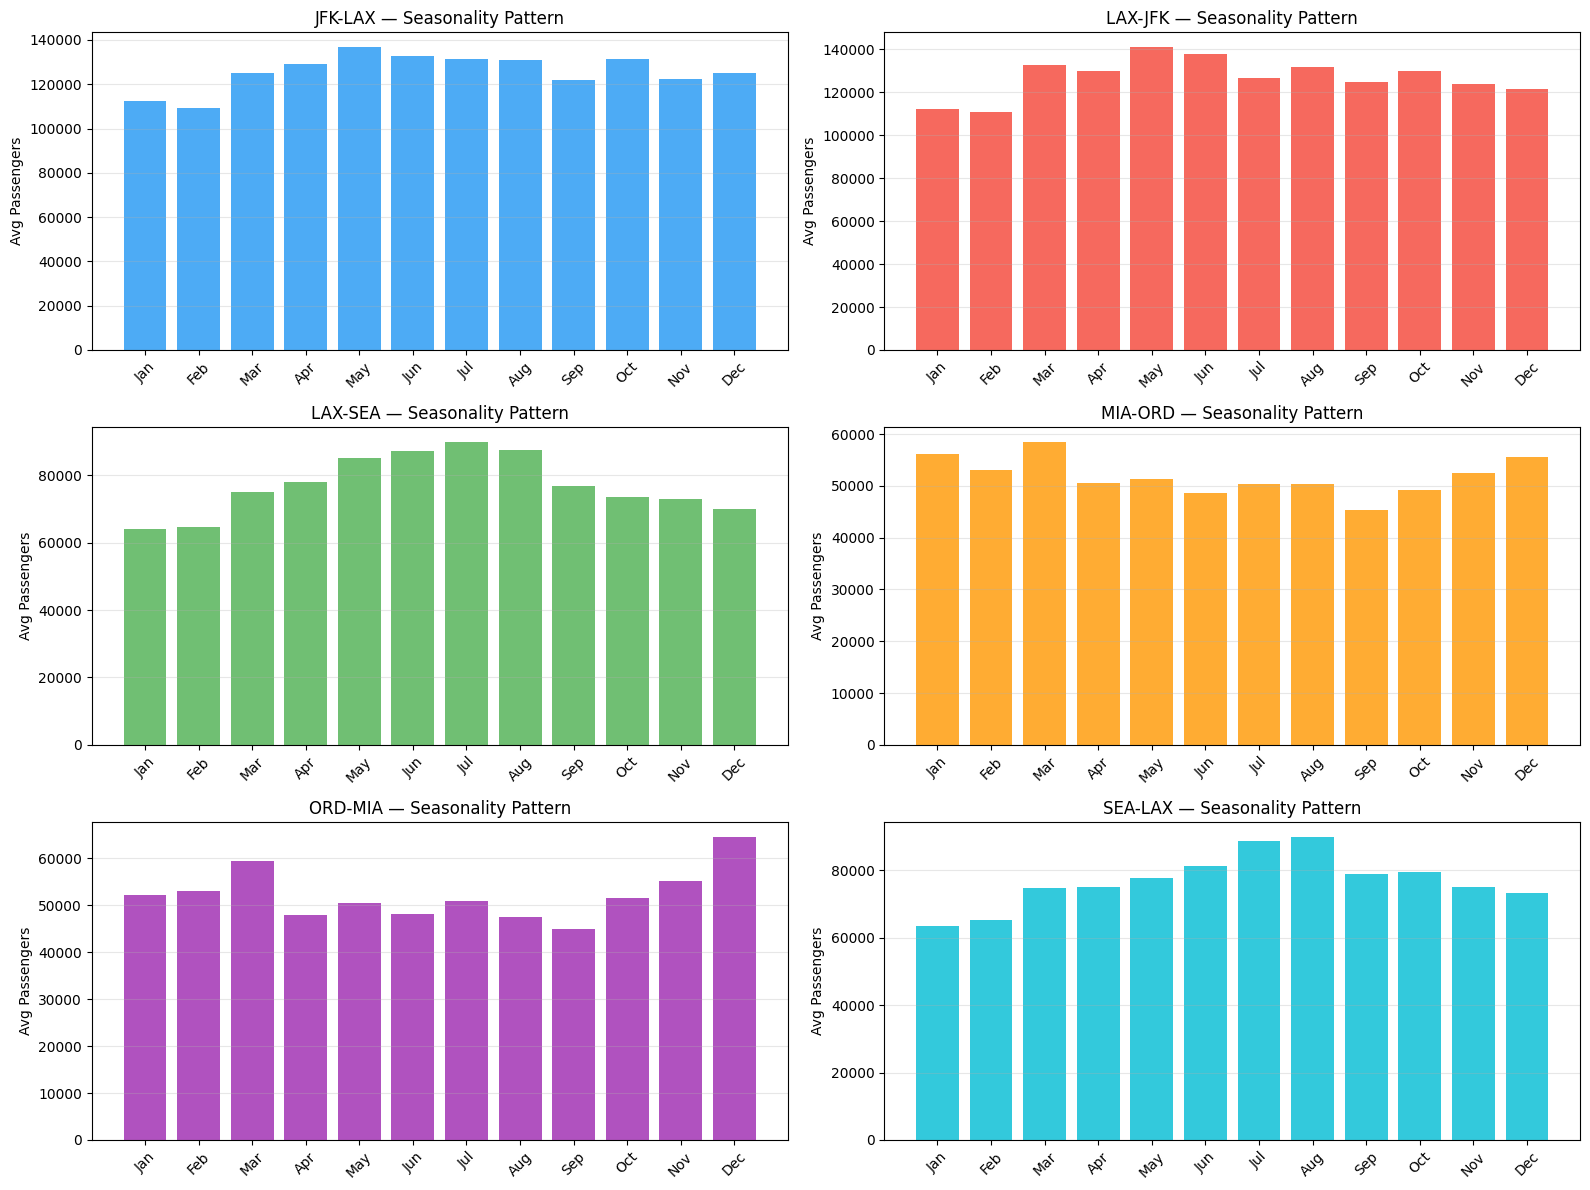

In [3]:
# Average demand by month across all years (excluding COVID)
df_no_covid = df[
    ~((df['DATE'] >= '2020-03-01') & (df['DATE'] <= '2021-06-01'))
].copy()

monthly_avg = (
    df_no_covid.groupby(['ROUTE', 'MONTH'])['total_passengers']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

for i, route in enumerate(routes):
    route_monthly = monthly_avg[monthly_avg['ROUTE'] == route]
    axes[i].bar(route_monthly['MONTH'], 
                route_monthly['total_passengers'],
                color=colors[i], alpha=0.8)
    axes[i].set_title(f'{route} — Seasonality Pattern', fontsize=12)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(month_names, rotation=45)
    axes[i].set_ylabel('Avg Passengers')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('notebooks/seasonality_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Quantify COVID impact per route
print("=== COVID DEMAND IMPACT ===\n")

for route in routes:
    route_df = df[df['ROUTE'] == route].copy()
    
    pre_covid = route_df[route_df['DATE'] < '2020-03-01']['total_passengers'].mean()
    covid_peak = route_df[
        (route_df['DATE'] >= '2020-03-01') & 
        (route_df['DATE'] <= '2021-06-01')
    ]['total_passengers'].mean()
    post_covid = route_df[route_df['DATE'] > '2021-06-01']['total_passengers'].mean()
    
    drop_pct = (covid_peak - pre_covid) / pre_covid * 100
    recovery_pct = (post_covid - pre_covid) / pre_covid * 100
    
    print(f"{route}:")
    print(f"  Pre-COVID avg:    {pre_covid:,.0f} passengers")
    print(f"  COVID period avg: {covid_peak:,.0f} passengers ({drop_pct:+.1f}%)")
    print(f"  Post-COVID avg:   {post_covid:,.0f} passengers ({recovery_pct:+.1f}% vs pre)")
    print()

=== COVID DEMAND IMPACT ===

JFK-LAX:
  Pre-COVID avg:    146,450 passengers
  COVID period avg: 37,678 passengers (-74.3%)
  Post-COVID avg:   115,314 passengers (-21.3% vs pre)

LAX-JFK:
  Pre-COVID avg:    148,255 passengers
  COVID period avg: 38,041 passengers (-74.3%)
  Post-COVID avg:   115,920 passengers (-21.8% vs pre)

LAX-SEA:
  Pre-COVID avg:    88,173 passengers
  COVID period avg: 31,305 passengers (-64.5%)
  Post-COVID avg:   71,270 passengers (-19.2% vs pre)

MIA-ORD:
  Pre-COVID avg:    53,108 passengers
  COVID period avg: 28,772 passengers (-45.8%)
  Post-COVID avg:   51,127 passengers (-3.7% vs pre)

ORD-MIA:
  Pre-COVID avg:    53,657 passengers
  COVID period avg: 28,135 passengers (-47.6%)
  Post-COVID avg:   51,537 passengers (-4.0% vs pre)

SEA-LAX:
  Pre-COVID avg:    87,648 passengers
  COVID period avg: 31,102 passengers (-64.5%)
  Post-COVID avg:   71,791 passengers (-18.1% vs pre)



In [5]:
print("=== LOAD FACTOR STATISTICS ===\n")
print("Load factor = passengers / available seats")
print("This is the capacity utilization — key RM metric\n")

lf_stats = (
    df.groupby('ROUTE')['avg_load_factor']
    .agg(['mean', 'min', 'max', 'std'])
    .round(3)
)
print(lf_stats)

print("\n\nLow load factor months (< 0.60) — below min viable threshold:")
low_lf = df[df['avg_load_factor'] < 0.60][['DATE', 'ROUTE', 'avg_load_factor', 'total_passengers']]
print(low_lf.sort_values('avg_load_factor').head(15).to_string())

=== LOAD FACTOR STATISTICS ===

Load factor = passengers / available seats
This is the capacity utilization — key RM metric

          mean    min    max    std
ROUTE                              
JFK-LAX  0.744  0.148  0.950  0.190
LAX-JFK  0.749  0.096  0.946  0.196
LAX-SEA  0.704  0.133  0.938  0.200
MIA-ORD  0.804  0.106  0.951  0.163
ORD-MIA  0.798  0.074  0.944  0.166
SEA-LAX  0.698  0.126  0.913  0.201


Low load factor months (< 0.60) — below min viable threshold:
          DATE    ROUTE  avg_load_factor  total_passengers
255 2020-04-01  ORD-MIA         0.074422            3348.0
75  2020-04-01  LAX-JFK         0.095535            3005.0
195 2020-04-01  MIA-ORD         0.106250            3701.0
315 2020-04-01  SEA-LAX         0.126448            5068.0
135 2020-04-01  LAX-SEA         0.133353            5301.0
15  2020-04-01  JFK-LAX         0.147933            3815.0
256 2020-05-01  ORD-MIA         0.235836            8767.0
18  2020-07-01  JFK-LAX         0.269650           